In [1]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 2: Data Loading & Exploration
# Dataset: APL_Logistics.csv (180,519 rows × 40 columns)
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Chart styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported. Ready to load data.")

✅ Libraries imported. Ready to load data.


In [2]:
# Load the APL Logistics dataset
# Note: this file uses 'latin-1' encoding

df = pd.read_csv('../data/APL_Logistics.csv', encoding='latin-1')

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💾 Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")

✅ Dataset loaded successfully!
📊 Shape: 180,519 rows × 40 columns
💾 Memory: 55.09 MB


In [3]:
# Look at first 5 rows
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [5]:
# Statistical summary of numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.980000,7.000000,31.520000,64.800000,911.800000
Sales per customer,180519.0,183.107607,120.043668,7.490000,104.380000,163.990000,247.400000,1939.990000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


TARGET VARIABLE: Late_delivery_risk

📊 Value Counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

📊 Percentage Distribution:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


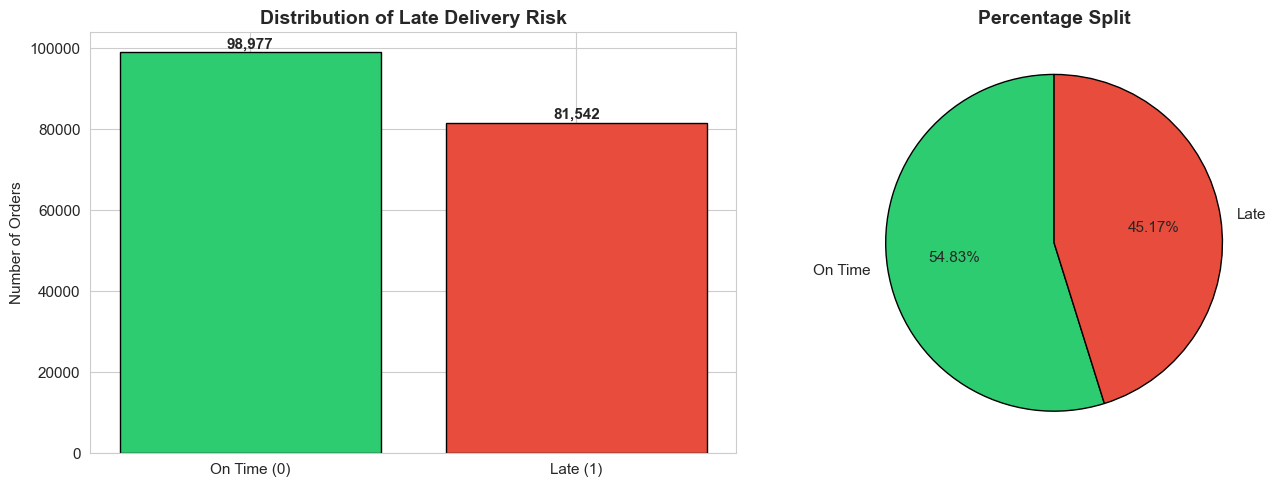


✅ Chart saved to: charts/01_target_distribution.png

💡 INSIGHT: ~55% of orders are late — this is a SERIOUS business problem!
💡 Class balance is reasonable — we may not need aggressive SMOTE


In [6]:
# ===== TARGET VARIABLE: Late_delivery_risk =====
print("="*60)
print("TARGET VARIABLE: Late_delivery_risk")
print("="*60)

print("\n📊 Value Counts:")
print(df['Late_delivery_risk'].value_counts())

print("\n📊 Percentage Distribution:")
print((df['Late_delivery_risk'].value_counts(normalize=True) * 100).round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['Late_delivery_risk'].value_counts()
axes[0].bar(['On Time (0)', 'Late (1)'], counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution of Late Delivery Risk', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['On Time', 'Late'], 
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.2f%%', startangle=90, 
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Percentage Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to: charts/01_target_distribution.png")
print("\n💡 INSIGHT: ~55% of orders are late — this is a SERIOUS business problem!")
print("💡 Class balance is reasonable — we may not need aggressive SMOTE")

In [7]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct.round(4)
}).sort_values('Missing_Count', ascending=False)

print("Columns with missing values:")
print(missing_df[missing_df['Missing_Count'] > 0])
print("\n💡 Only 11 missing cells out of 7.2 million — dataset is super clean!")

Columns with missing values:
                  Missing_Count  Missing_Percentage
Customer Lname                8              0.0044
Customer Zipcode              3              0.0017

💡 Only 11 missing cells out of 7.2 million — dataset is super clean!


In [8]:
# Check key categorical columns
print("="*60)
print("DELIVERY STATUS")
print("="*60)
print(df['Delivery Status'].value_counts())

print("\n" + "="*60)
print("SHIPPING MODE")
print("="*60)
print(df['Shipping Mode'].value_counts())

print("\n" + "="*60)
print("MARKET")
print("="*60)
print(df['Market'].value_counts())

print("\n" + "="*60)
print("CUSTOMER SEGMENT")
print("="*60)
print(df['Customer Segment'].value_counts())

DELIVERY STATUS
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

SHIPPING MODE
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

MARKET
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

CUSTOMER SEGMENT
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64


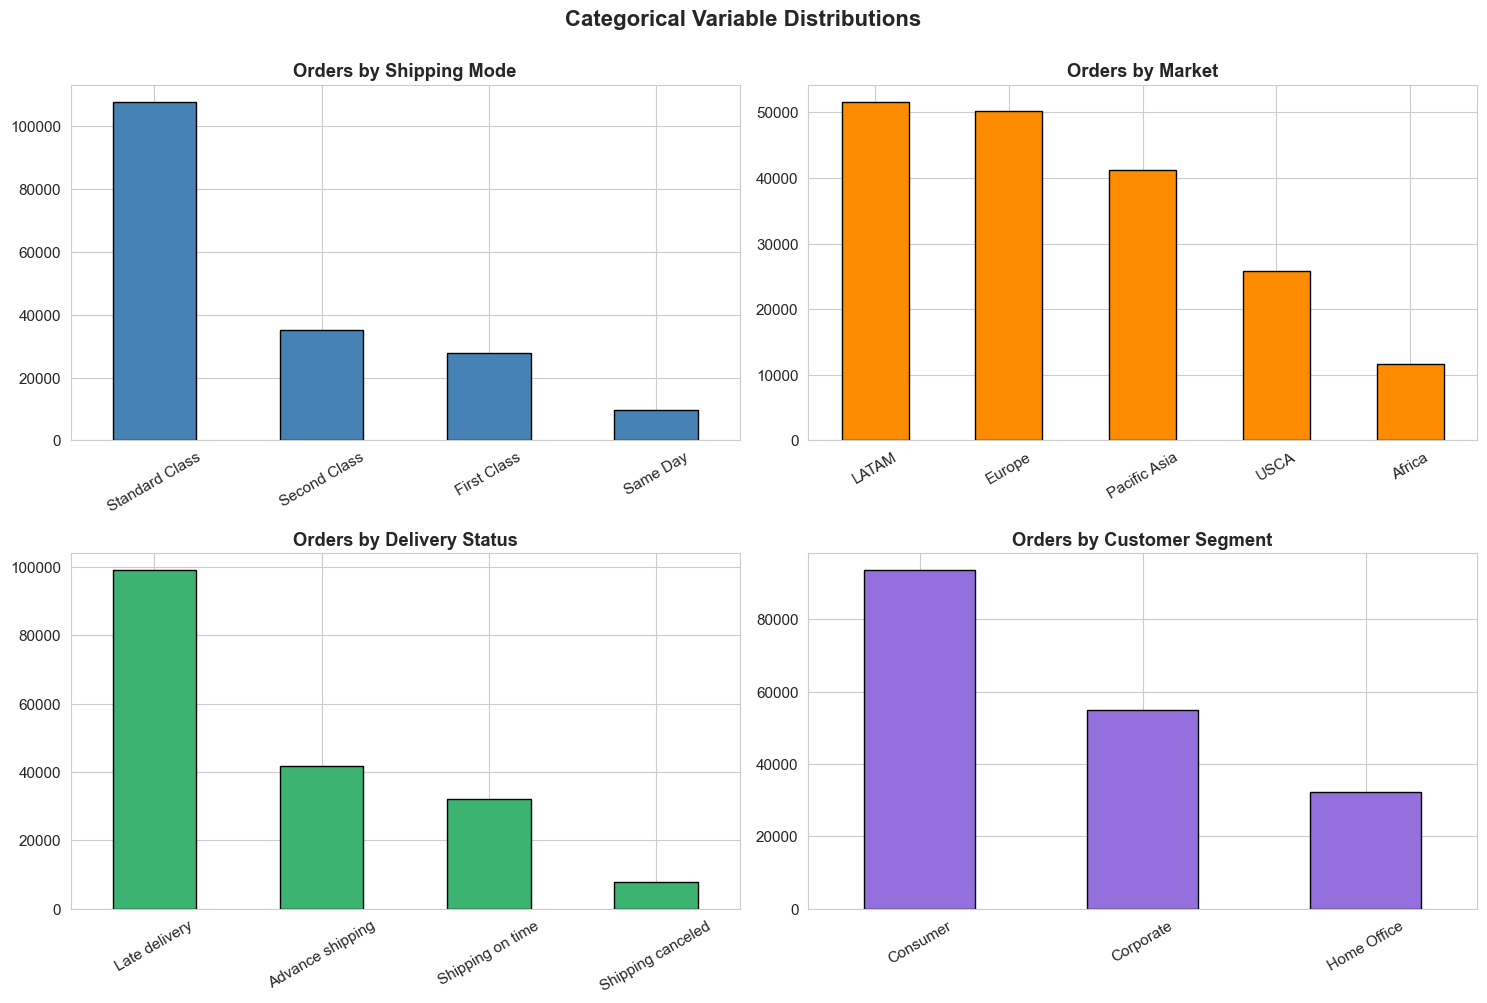


✅ Chart saved: charts/02_categorical_distributions.png


In [9]:
# Visualize categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Shipping Mode
df['Shipping Mode'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Orders by Shipping Mode', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)

# Market
df['Market'].value_counts().plot(
    kind='bar', ax=axes[0,1], color='darkorange', edgecolor='black')
axes[0,1].set_title('Orders by Market', fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=30)

# Delivery Status
df['Delivery Status'].value_counts().plot(
    kind='bar', ax=axes[1,0], color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Orders by Delivery Status', fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=30)

# Customer Segment
df['Customer Segment'].value_counts().plot(
    kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Orders by Customer Segment', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../charts/02_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/02_categorical_distributions.png")

In [10]:
# ===== DATA LEAKAGE IDENTIFICATION =====
print("🚨 DATA LEAKAGE WARNING")
print("="*60)
print("These columns CANNOT be used as features:")
print("They contain information only available AFTER delivery happens.\n")

leakage_columns = {
    'Days for shipping (real)': 'Actual shipping days — UNKNOWN before delivery',
    'Delivery Status': 'Directly tells late/on-time — IS the answer',
    'Order Status': 'Filled after order completes'
}

for col, reason in leakage_columns.items():
    print(f"❌ {col}")
    print(f"   → {reason}\n")

print("="*60)
print("✅ We will DROP these in Phase 3 before training the model.")
print("✅ This is CRITICAL — using them = fake 99% accuracy = useless model")

🚨 DATA LEAKAGE WARNING
These columns CANNOT be used as features:
They contain information only available AFTER delivery happens.

❌ Days for shipping (real)
   → Actual shipping days — UNKNOWN before delivery

❌ Delivery Status
   → Directly tells late/on-time — IS the answer

❌ Order Status
   → Filled after order completes

✅ We will DROP these in Phase 3 before training the model.
✅ This is CRITICAL — using them = fake 99% accuracy = useless model


In [11]:
# Save Phase 2 summary
summary = f"""
PHASE 2 SUMMARY — Data Exploration Complete
=============================================
Dataset: APL_Logistics.csv
Total Records: {df.shape[0]:,}
Total Columns: {df.shape[1]}
Memory: {df.memory_usage().sum() / 1024**2:.2f} MB
Encoding: latin-1
Duplicates: {df.duplicated().sum()}

TARGET VARIABLE: Late_delivery_risk
  - 0 (On Time): {(df['Late_delivery_risk']==0).sum():,} ({(df['Late_delivery_risk']==0).mean()*100:.2f}%)
  - 1 (Late):    {(df['Late_delivery_risk']==1).sum():,} ({(df['Late_delivery_risk']==1).mean()*100:.2f}%)

MISSING VALUES: Only 11 cells (effectively zero)
  - Customer Lname: 8
  - Customer Zipcode: 3

COLUMN TYPES:
  - Numeric: {df.select_dtypes(include=[np.number]).shape[1]}
  - Categorical: {df.select_dtypes(include=['object']).shape[1]}

DATA LEAKAGE COLUMNS (will be dropped in Phase 3):
  1. Days for shipping (real)
  2. Delivery Status
  3. Order Status

Key Markets: LATAM, Europe, Pacific Asia, USCA, Africa
Key Shipping Modes: Standard, Second, First, Same Day

Phase 2 Complete. Ready for Phase 3 (Data Cleaning).
"""
print(summary)

with open('../phase2_summary.txt', 'w') as f:
    f.write(summary)
print("\n✅ Summary saved to: phase2_summary.txt")


PHASE 2 SUMMARY — Data Exploration Complete
Dataset: APL_Logistics.csv
Total Records: 180,519
Total Columns: 40
Memory: 55.09 MB
Encoding: latin-1
Duplicates: 0

TARGET VARIABLE: Late_delivery_risk
  - 0 (On Time): 81,542 (45.17%)
  - 1 (Late):    98,977 (54.83%)

MISSING VALUES: Only 11 cells (effectively zero)
  - Customer Lname: 8
  - Customer Zipcode: 3

COLUMN TYPES:
  - Numeric: 21
  - Categorical: 19

DATA LEAKAGE COLUMNS (will be dropped in Phase 3):
  1. Days for shipping (real)
  2. Delivery Status
  3. Order Status

Key Markets: LATAM, Europe, Pacific Asia, USCA, Africa
Key Shipping Modes: Standard, Second, First, Same Day

Phase 2 Complete. Ready for Phase 3 (Data Cleaning).


✅ Summary saved to: phase2_summary.txt
